In [1]:
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

I0000 00:00:1781761559.974503   10709 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781761560.034119   10709 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781761561.925510   10709 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
p458까지 복습. 문제3개 메일보이기

In [2]:
def build_model(a, b):
    inputs = keras.layers.Input(shape= (a,b))
    flatten  = keras.layers.Flatten()
    outputs1 = keras.layers.Dense(units=20, activation='relu')
    outputs2 = keras.layers.Dropout(rate=0.3)
    outputs3 = keras.layers.Dense(units=10, activation='softmax')
    model = keras.Sequential([inputs, flatten, outputs1, outputs2,  outputs3 ])
    return model

In [23]:
(X_train, y_train) ,  (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [24]:
X_train.shape

(60000, 28, 28)

In [28]:
X_train = X_train[:600]
y_train = y_train[:600]

In [30]:
X_train.shape

(600, 28, 28)

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.2)

In [32]:
model = build_model( 28, 28)

In [33]:
model.compile(loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [36]:
early_stop = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
ckpt = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val,y_val ), verbose=1, callbacks=[early_stop, ckpt ]  )

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2354 - loss: 1.9885 - val_accuracy: 0.2917 - val_loss: 2.6648
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2604 - loss: 2.0390 - val_accuracy: 0.2333 - val_loss: 2.3378
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2104 - loss: 2.1214 - val_accuracy: 0.2583 - val_loss: 2.1735
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2937 - loss: 1.9094 - val_accuracy: 0.3083 - val_loss: 2.3972
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3167 - loss: 2.1511 - val_accuracy: 0.2917 - val_loss: 2.3545
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2750 - loss: 1.9196 - val_accuracy: 0.3333 - val_loss: 2.3159


In [37]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2392 - loss: 2.3329


[2.332908868789673, 0.23919999599456787]

In [24]:
history.history

{'accuracy': [0.7319375276565552,
  0.7816666960716248,
  0.7908124923706055,
  0.7961875200271606,
  0.7959166765213013,
  0.7998958230018616,
  0.801604151725769,
  0.80447918176651,
  0.8062083125114441,
  0.8054583072662354],
 'loss': [21.483625411987305,
  16.674720764160156,
  15.678767204284668,
  15.450669288635254,
  15.234347343444824,
  15.020868301391602,
  15.056066513061523,
  14.684684753417969,
  14.506956100463867,
  14.603500366210938],
 'val_accuracy': [0.7910000085830688,
  0.7735833525657654,
  0.781416654586792,
  0.8082500100135803,
  0.796999990940094,
  0.8300833106040955,
  0.8269166946411133,
  0.7930833101272583,
  0.8063333630561829,
  0.8222500085830688],
 'val_loss': [14.442618370056152,
  15.369048118591309,
  19.19329833984375,
  13.189780235290527,
  16.418983459472656,
  11.110651016235352,
  10.995454788208008,
  15.603418350219727,
  15.665945053100586,
  12.463300704956055]}

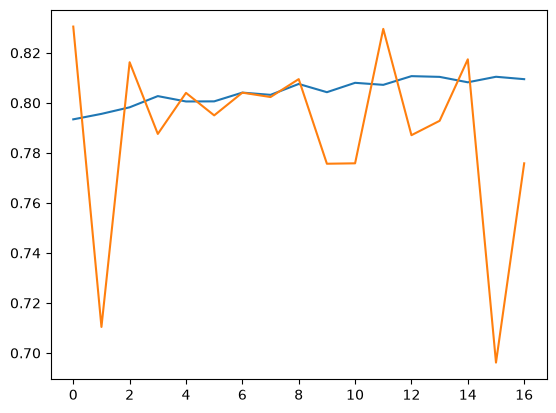

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

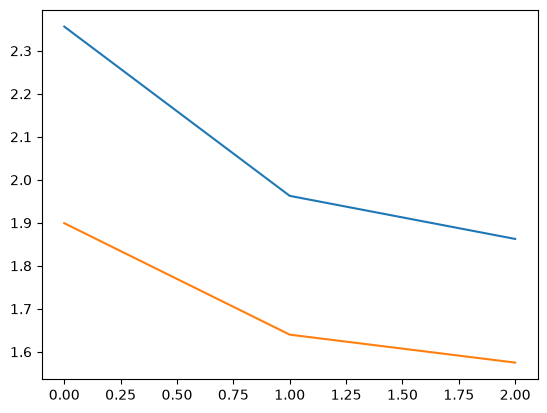

In [6]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [7]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3540 - loss: 1.5831


[1.5830605030059814, 0.3540000021457672]

In [ ]:
fashionMNIST 데이터셋으로, DNN모델 만들고, 훈련시키고, 예측하기

In [8]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3540 - loss: 1.5831


[1.5830605030059814, 0.3540000021457672]

### 방법 1

In [10]:
# 훈련이 끝난 모델 저장하기
model.save('model1.keras')

In [11]:
# 받아온 모델 로딩하기
my_model = keras.models.load_model('model1.keras')

In [13]:
my_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3540 - loss: 1.5831


[1.5830605030059814, 0.3540000021457672]

## 방법 2

In [16]:
# 훈련이 끝난 모델 저장하기
model.save_weights('model2.weights.h5')

In [20]:
# 1. 모델 아키텍쳐를 만들어준다
model = build_model(28, 28)

# 2. 가중치를 위치에 맞게 넣는다.
model.load_weights('model2.weights.h5')

In [21]:
my_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3540 - loss: 1.5831


[1.5830605030059814, 0.3540000021457672]

In [1]:
import keras

I0000 00:00:1781488281.062213     194 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781488281.112997     194 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781488282.448531     194 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(X_train, y_train) ,  (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape

(60000, 28, 28)

In [7]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 35.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 46.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 46.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 11.3 MB/s eta 0:00:00


In [8]:
import matplotlib.pyplot as plt

In [11]:
X_train[0, :, :]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

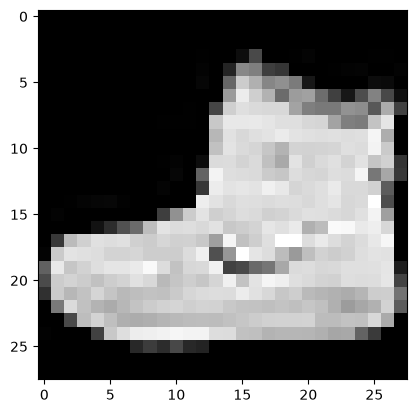

In [19]:
plt.imshow(X_train[0, : , :], cmap='gray')  # 첫번째 것은 신발
# 두번째 것은 ?  티셔츠
# 마지막 번째 (60000번째) 것은?

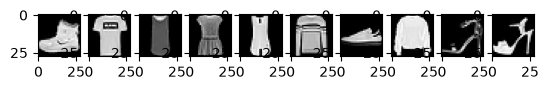

In [28]:
fig, ax = plt.subplots(1, 10)
for i in range(10):
    ax[i].imshow(X_train[i], cmap='gray')


In [32]:
X_train.shape

(60000, 28, 28)

In [33]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [30]:
X_test.shape

(10000, 28, 28)

In [34]:
y_test.shape

(10000,)

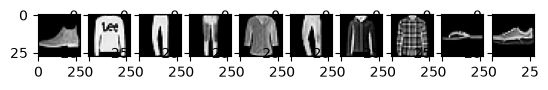

In [31]:
fig, ax = plt.subplots(1, 10)
for i in range(10):
    ax[i].imshow(X_test[i], cmap='gray')

In [35]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 11.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 27.4 MB/s eta 0:00:0000:0100:01


In [36]:
import sklearn

In [37]:
from sklearn.tree import  DecisionTreeClassifier

In [40]:
X_train.shape

(60000, 28, 28)

In [41]:
X_train.reshape(-1, 28*28)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784), dtype=uint8)

#### scikit-learn 으로 분류해 보기

In [38]:
dt = DecisionTreeClassifier()

In [ ]:
X_train = X_train.reshape(-1, 28*28)

In [43]:
X_train.shape

(60000, 784)

In [45]:
X_train = X_train[:1000, :]

In [48]:
y_train = y_train[:1000]

In [49]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [51]:
X_test.shape

(10000, 28, 28)

In [52]:
X_test = X_test.reshape(-1, 28*28)

In [53]:
pred = dt.predict(X_test)
pred

array([9, 9, 1, ..., 3, 1, 7], shape=(10000,), dtype=uint8)

In [54]:
y_test

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

In [57]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
print(accuracy_score(y_test, pred))

0.6621


## 딥러닝으로 해 보기

In [ ]:
inputs = keras.layers.Input(shape= (784,))
dense = keras.layers.Dense(units=10, activation='softmax')
model = keras.Sequential([inputs, dense])
model.compile(loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=15)
model.evaluate(X_test, y_test)

In [ ]:
inputs = keras.layers.Input(shape= (28,28))
keras.layers.Flatten()

## 딥러닝 해보기 2

In [95]:
from keras.layers import Input, Dense
from keras import Sequential

- 데이터셋 준비

In [97]:
(X_train, y_train) ,  (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [98]:
## Min Max Scaling  0~1 값 조정하기 
X_train = X_train/255.0
X_test = X_test/255.0

In [99]:
# shape 바꾸기
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

In [101]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val  = train_test_split(X_train, y_train, test_size=.2, random_state=42)

In [128]:
X_tr

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(48000, 784))

- 모델 만들기

In [125]:
inputs = Input(shape=(784,))
hidden = Dense(units=100, activation='sigmoid', name='hidden')
hidden = Dense(units=100, activation='sigmoid', name='hidden1')
hidden = Dense(units=100, activation='sigmoid', name='hidden2')
hidden = Dense(units=100, activation='sigmoid', name='hidden3')
outputs  = Dense(units=10, activation='softmax', name = 'output')
model = Sequential([inputs, hidden, outputs])

In [126]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │           909 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,409 (310.19 KB)

 Trainable params: 79,409 (310.19 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_tr, y_tr, epochs= 5)

Epoch 1/5


W0000 00:00:1781504587.273578     891 op_kernel.cc:1858] OP_REQUIRES failed at sparse_xent_op.cc:103 : INVALID_ARGUMENT: Received a label value of 9 which is outside the valid range of [0, 9).  Label values: 6 2 9 7 8 8 3 1 6 9 1 5 9 5 9 5 2 1 3 8 1 6 1 6 7 2 2 3 5 9 2 3
W0000 00:00:1781504587.273610     891 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: Received a label value of 9 which is outside the valid range of [0, 9).  Label values: 6 2 9 7 8 8 3 1 6 9 1 5 9 5 9 5 2 1 3 8 1 6 1 6 7 2 2 3 5 9 2 3
	 [[{{function_node __inference_one_step_on_data_77358}}{{node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits}}]]


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/user/DL/v_DL/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/user/DL/v_DL/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/home/user/DL/v_DL/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/home/user/DL/v_DL/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/home/user/DL/v_

In [120]:
# 평가하기 (정확도)
model.evaluate(X_val, y_val)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8698 - loss: 0.3579


[0.3578987717628479, 0.8698333501815796]

In [ ]:
p358부터 읽어보기 